In [196]:
import numpy as np
import scipy as sp
import py3Dmol
import matplotlib.pyplot as plt

In [178]:
# class for reading and writing xyz files

class Molecule:

    def __init__(self, xyz_string):

        self.xyz = xyz_string

        # number of atoms
        self.nat = int(self.xyz.split('\n')[0])

        # atom types & coordinates
        at = []
        coord = []
        for line in self.xyz.split('\n')[2:]:
            if line != '':
                a, x, y, z = line.split()
                at += [a]
                coord += [[x, y, z]]
        self.atoms = at
        self.coords = np.array(coord, dtype=float)


    @classmethod
    def from_file(cls, filename: str):
        with open(filename, 'r') as f:
            xyz_string = f.read()
        return cls(xyz_string)


    # centre of mass coordinates
    def com(self):
        return np.ones((self.nat,)) @ self.coords


    # write xyz string to file
    def save(self, filename, comment=''):
        split_xyz = self.xyz.splitlines()
        split_xyz[1] = comment
        commented_xyz = '\n'.join(split_xyz)
        with open(filename, 'w') as f:
            f.write(commented_xyz)
        return


    # create distorted molecule object along displacement vector
    def distort(self, vector, amplitude):
        new_coords = self.coords + amplitude * vector.reshape(self.nat, 3)
        new_xyz = f'{self.nat}\n\n'
        for a, r in zip(self.atoms, new_coords):
            new_xyz += f'{a}    {r[0]}    {r[1]}    {r[2]}\n'
        return Molecule(new_xyz)



In [179]:
# class for reading normal modes

class Vibration:

    def __init__(self, filename):
        
        # lines of the hessian file
        with open(filename, 'r') as file:
           lines = file.readlines()
        self.lines = lines

        # number of modes
        i = self.lines.index('$vibrational_frequencies\n')
        self.nvib = int(self.lines[i+1])

        # hessian matrix
        self.hessian = self.read_hessian()

        # vibrational frequencies
        self.freqs = self.read_freqs()

        # normal mode vectors (cartesian, normalized)
        self.modevecs = self.read_modevecs()


    # read matrix from list of lines
    def readmatrix(self, lines):

        # check if all characters in a line are numeric (True for '' too)
        def allnumeric(line):
            return all([c.isnumeric() for c in line.split()])

        # find first line where all characters are numeric (column indices)
        for i,line in enumerate(lines):
            if line != '\n' and allnumeric(line):
                break
                    
        # find second line where it happens to obtain number of rows
        for nrows,line in enumerate(lines[i+1:]):
            if allnumeric(line):
                break
                    
        # initialize matrix (number or columns unknow)
        matrix = np.empty((nrows,0), dtype=float)

        # read matrix block by block line by line
        for line in lines[i:]:
            
            # reset block when reaching another column index line
            if allnumeric(line):
                block = np.empty((0,len(line.split())), dtype=float)

            # scan rows and append block to matrix
            if not(allnumeric(line)):
                entries = np.array(line.split()[1:], dtype=float)
                block = np.vstack((block, entries))
                r = int(line.split()[0])
                if r == nrows - 1:
                    matrix = np.hstack((matrix, block))

            # exit loop when encountering empty line (end of matrix)
            if line == '\n':
                break

        return matrix


    # vibrational frequencies
    def read_freqs(self):
        i = self.lines.index('$vibrational_frequencies\n')
        vibfreq = []
        for line in self.lines[i+2:]:
            if line == '\n':
                break
            else:
                vibfreq += [line.split()[1]]
        vibfreq = np.array(vibfreq, dtype=float)
        return vibfreq


    # normal mode displacement vectors (normalised)
    def read_modevecs(self):
        i = self.lines.index('$normal_modes\n')
        return self.readmatrix(self.lines[i+2:])


    # hessian matrix
    def read_hessian(self):
        i = self.lines.index('$hessian\n')
        return self.readmatrix(self.lines[i+2:])


In [184]:
v = Vibration('dimer_opt_modes.hess')
vec = v.modevecs[:,11]
ampli = 2

mol_eq = Molecule.from_file('dimer_opt.xyz')
mol_pd = mol_eq.distort(vec, +ampli)
mol_nd = mol_eq.distort(vec, -ampli)


view = py3Dmol.view()

view.addModel(mol_eq.xyz, 'xyz')
view.addModel(mol_pd.xyz, 'xyz')
view.addModel(mol_nd.xyz, 'xyz')


view.setStyle({'model':0, 'not':{'elem':'H','elem':'C'}}, {'stick':{'colorscheme':'grayCarbon'}})
view.setStyle({'model':1, 'not':{'elem':'H'}}, {'stick':{'colorscheme':'blueCarbon'}})
view.setStyle({'model':2, 'not':{'elem':'H'}}, {'stick':{'colorscheme':'redCarbon'}})


view.setBackgroundColor('white')
view.zoomTo()
view.rotate(-90, 'x')
view.show()




3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [416]:
# generate distortions

ampli = 1e-4

mol_eq = Molecule.from_file('dimer_opt.xyz')

v = Vibration('dimer_opt_modes.hess')
vecs = v.modevecs().T

for i,vec in enumerate(vecs[6:]):
    mol_eq.distort(vec, +ampli).save(f'dimer_opt_dist+{i}.xyz',
                                              comment=f'+{ampli} angstrom along mode {v.freqs()[6+i]} invcm')
    mol_eq.distort(vec, -ampli).save(f'dimer_opt_dist-{i}.xyz',
                                              comment=f'-{ampli} angstrom along mode {v.freqs()[6+i]} invcm')


In [180]:
# class for reading output files

class Output:

    def __init__(self, filename):

        self.filename = filename

        with open(self.filename, 'r') as f:
            lines = f.readlines()
        self.lines = lines

        # number of atoms
        for line in self.lines:
            if line.startswith('Number of atoms'):
                nat = int(line.split()[-1])
        self.nat = nat

        # number of basis functions
        for line in self.lines:
            if line.startswith('Number of basis functions'):
                nbasis = int(line.split()[-1])
        self.nbasis = nbasis


    # one electron matrix
    def one(self):
            return self._read_matrix('ONE ELECTRON MATRIX (AU)\n')

    # Fock matrix
    def fock(self):
        return self._read_matrix('FOCK\n')

    # overlap matrix
    def ovlp(self):
        return self._read_matrix('OVERLAP MATRIX\n')

    # molecular orbitals
    def mos(self):
        return self._read_orbitals()

    # HOMO index
    def homo(self):
        i0 = self.lines.index('ORBITAL ENERGIES\n') + 4
        for line in self.lines[i0:]:
            if float(line.split()[1]) == 0.0:
                break
        return int(line.split()[0]) - 1


    def _read_matrix(self, header):

        # header index
        i0 = self.lines.index(header)

        # number of columns per block
        cpb = len(self.lines[i0+2].split())

        # number of blocks (last one might have fewer columns)
        nblocks = -(self.nbasis // -cpb)

        # initialize 
        matrix = np.empty((self.nbasis,0), dtype=float)

        for b in range(nblocks):
            # beginning of the block
            i = i0 + 3 + b * (self.nbasis + 1)
            # initialize block
            c = len(self.lines[i].split()) - 1
            blck = np.zeros((self.nbasis, c), dtype=float)
            # collect block data and append it to matrix
            for j in range(self.nbasis):
                blck[j] = np.array(self.lines[i + j].split()[1:], dtype=float)
            matrix = np.hstack((matrix, blck))

        return matrix


    def _read_orbitals(self):

        # header index
        i0 = self.lines.index('MOLECULAR ORBITALS (RHF, ROHF)\n')

        # number of columns per block
        cpb = len(self.lines[i0+2].split())

        # number of blocks (last one might have fewer columns)
        nblocks = -(self.nbasis // -cpb)

        # initialize 
        matrix = np.empty((self.nbasis,0), dtype=float)

        '''
        The following loop is very quick and dirty and not general at all.
        Large values of negative entries > 10 becomes problematic if there is
        no space between columns. TO DO: Replace with something more robust.
        '''
        for b in range(nblocks):
            # beginning of the block
            i = i0 + 6 + b * (self.nbasis + 4)
            # number of columns in this block
            c = len(self.lines[i - 4].split())
            # initialize block
            blck = np.zeros((self.nbasis, c), dtype=float)
            # collect block data and append it to matrix
            for j in range(self.nbasis):
                #blck[j] = np.array(self.lines[i + j].split()[2:], dtype=float)
                line = self.lines[i + j]
                blck_txt = [line[16+k*10:16+(k+1)*10] for k in range(c)]
                blck[j] = np.array(blck_txt, dtype=float)
            matrix = np.hstack((matrix, blck))

        return matrix
    

relative distance from identity: 0.00044728392444366645


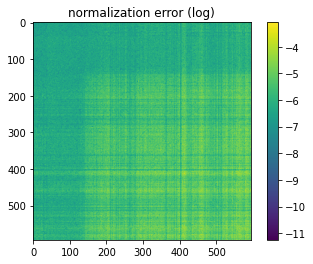

In [187]:
# Sanity check: MO matrix (C) and ovlp matrix should combine to give the identity

out = Output('dimer_eq.out')
S = out.ovlp()
C = out.mos()
id = C.T @ S @ C
ey = np.eye(id.shape[0])
print('relative distance from identity:', np.linalg.norm(id-ey)/np.linalg.norm(ey))

plt.figure()
plt.imshow(np.log10(np.abs(id-ey)))
plt.title(r'normalization error (log)')
plt.colorbar()
plt.show()

In [210]:
out = Output('dimer_eq.out')
F = out.fock()
H = out.one()
print(np.diag(H)[:10])
print(np.diag(F)[:10])

[-48.625214 -35.468589 -34.524715 -34.852286 -34.857275 -34.177407
 -31.662149 -32.776817 -32.614892 -32.218168]
[-10.295738  -1.094081  -0.090292  -0.16956   -0.214634  -1.262978
  -0.349675  -0.58992   -0.731816   1.679568]


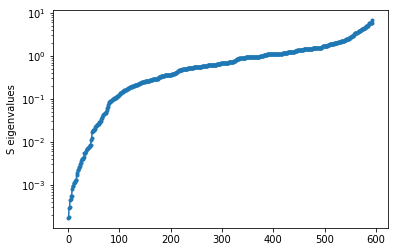

In [189]:
# eigenvalues of the overlap matrix
Seigval = np.linalg.eigvalsh(S)
plt.figure()
plt.semilogy(Seigval,'.-')
plt.ylabel('S eigenvalues')
plt.show()

relative distance between MOs: 1.36698293457193
210.1199371137692


<ipython-input-194-de14535851a9>:9: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(Cloc-C)))


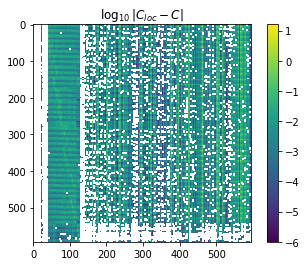

In [194]:
# localized orbitals
outloc = Output('../test02loc/noiter_loc.out')
Cloc = outloc.mos()
print('relative distance between MOs:', np.linalg.norm(Cloc - C) / np.linalg.norm(C))

plt.figure()
plt.imshow(np.log10(np.abs(Cloc-C)))
plt.title(r'$\log_{10}|C_{loc} - C|$')
plt.colorbar()
plt.show()

In [207]:
# hamiltonian in the HOMO-1, ..., LUMO+1 subspace

outeq = Output('dimer_eq.out')
outloc = Output('../test02loc/noiter_loc.out')

# sinv F sinv s C = s C e

h = out.homo()
S = out.ovlp()
# canonical (Lowdin)
X =  sp.linalg.fractional_matrix_power(S, -0.5)
Xi = sp.linalg.fractional_matrix_power(S, +0.5)
C = Xi @ out.mos()
Cloc = Xi @ outloc.mos()

# loop over distortions
i = 0
outdist_p = Output(f'dimer_opt_dist+{i}.out')
outdist_n = Output(f'dimer_opt_dist-{i}.out')

H_p = X.conj().T @ outdist_p.one() @ X
H_n = X.conj().T @ outdist_n.one() @ X

H4_p = C[:,h-1::h+3].T @ H_p @ C[:,h-1::h+3]
H4_n = C[:,h-1::h+3].T @ H_n @ C[:,h-1::h+3]

print('Positive displacement:')
print(H4_p)
print('')
print('Negative displacement:')
print(H4_n)

Positive displacement:
[[-2.96212842e+01  4.75700886e-06 -1.39919293e-04 -1.43497092e-02]
 [ 4.75700887e-06 -2.74668205e+01 -2.16399592e-04 -2.09701403e-05]
 [-1.39919293e-04 -2.16399592e-04 -2.50784237e+01  2.70654309e-04]
 [-1.43497092e-02 -2.09701404e-05  2.70654309e-04 -2.70576769e+01]]

Negative displacement:
[[-2.96212953e+01  4.41495891e-06 -1.41247318e-04 -1.44644426e-02]
 [ 4.41495892e-06 -2.74668219e+01 -2.10007579e-04 -2.56476614e-05]
 [-1.41247318e-04 -2.10007579e-04 -2.50784366e+01  2.41775801e-04]
 [-1.44644426e-02 -2.56476617e-05  2.41775802e-04 -2.70576726e+01]]


In [213]:
outeq = Output('dimer_eq.out')
h = out.homo()
S = out.ovlp()
# canonical (Lowdin)
X =  sp.linalg.fractional_matrix_power(S, -0.5)
Xi = sp.linalg.fractional_matrix_power(S, +0.5)
C = Xi @ out.mos()
Cloc = Xi @ outloc.mos()


F = X.conj().T @ outeq.fock() @ X * 27.211386 * 1000
F4 = C[:,h-1::h+3].T @ F @ C[:,h-1::h+3]
print(F4)

[[-6.88004487e+03  4.15005182e-03  8.99477564e-03  7.69930254e-02]
 [ 4.15005184e-03  1.99788144e+04  2.40953971e-02  3.56105104e-02]
 [ 8.99477564e-03  2.40953970e-02  4.19325367e+04  1.72080062e-01]
 [ 7.69930254e-02  3.56105106e-02  1.72080062e-01  6.78552227e+04]]


In [ ]:
# read distorted molecules
v = Vibration('dimer_opt_modes.hess')
freqs = v.freqs
nvib = v.nvib

for i in range(nvib-6):

    # read output files
    pvOut = Output(f'dimer_opt_dist+{i}.out')
    nvOut = Output(f'dimer_opt_dist-{i}.out')

    # one electron matrix
    pvH1 = pvOut.one
    nvH1 = nvOut.one


In [ ]:
v = Vibration('dimer_opt_modes.hess')

In [214]:
outeq = Output('dimer_eq.out')
h = out.homo()
print(h)

128
